In [ ]:
import importlib
import os
from omegaconf import OmegaConf
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import scripts.generate_training_data
importlib.reload(scripts.generate_training_data)
from scripts.generate_training_data import main, gif_that

cfg = OmegaConf.load('..\config\default.yaml')
q_traj1 = main(cfg)

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
C:\Users\C5044892\AppData\Local\Temp\ipykernel_15108\2419290743.py:12: SyntaxWarning: invalid escape sequence '\c'
  cfg = OmegaConf.load('..\config\default.yaml')
2026-09-11 19:09:02,237 INFO scripts.generate_training_data: Requested device: cpu, using device: CPU


2026-09-11 19:09:02,323 INFO scripts.generate_training_data: Fine timestep is 1e+03s and coarsened timestep is 1.6e+04s. Model spinup for 0.00 days (~1.1e+02 eddy turnover times). Training horizon is 2000 low-res steps (~370.37 days). Validation plotting window is 1000 steps (~185.19 days).


Spinup time in model units: 0.0
model hr dt: 2.9862531882592125e-05
Spinup in steps: 0


2026-09-11 19:28:35,524 WARNING matplotlib.animation: MovieWriter ffmpeg unavailable; using Pillow instead.


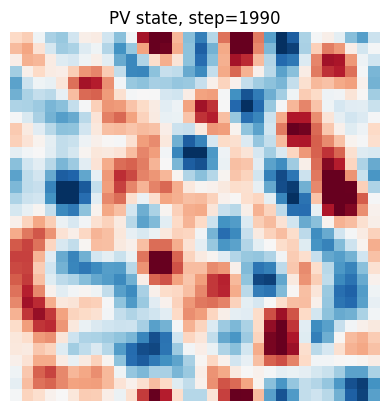

In [53]:
q_traj3 = q_traj1[1:]
out_file= os.path.join(cfg.filepaths.out_dir, "plot.gif")
gif_that(q_traj1, out_file=out_file, cadence=10)

In [54]:
# Test the forcing-only kinetic-energy injection rate.
# Starting from q=0 removes the cross term and isolates the Ito forcing contribution.
import jax
import jax.numpy as jnp
from model.core.model import QGM

def forcing_energy_test(nx, n_samples=256):
    params = dict(OmegaConf.to_container(cfg.params, resolve=True))
    params["nx"] = nx
    params["ny"] = nx
    params["dt"] = float(cfg.plotting.dt)
    model = QGM(params)

    zero_qh = jnp.zeros(
        (model.nz, model.ny, model.nx // 2 + 1),
        dtype=jnp.complex64,
    )
    zero_state = model.set_initial(
        zero_qh,
        _q_shape=(model.ny, model.nx),
    )
    layer_weights = model.Lz / jnp.sum(model.Lz)

    def kinetic_energies(qh):
        full_state = model.get_full_state(
            model.set_initial(qh, _q_shape=(model.ny, model.nx))
        )
        layer_energy = 0.5 * jnp.mean(
            full_state.u**2 + full_state.v**2,
            axis=(-2, -1),
        )
        equal_layer_energy = jnp.mean(layer_energy)
        weighted_layer_energy = jnp.sum(layer_weights * layer_energy)
        return equal_layer_energy, weighted_layer_energy

    keys = jax.random.split(jax.random.PRNGKey(1000 + nx), n_samples)
    equal_energies = []
    weighted_energies = []
    for forcing_key in keys:
        forcing = model.do_stochastic_forcing(
            zero_state,
            forcing_key=forcing_key,
        )
        forced_state = zero_state.update(qh=zero_state.qh + forcing.qh)
        equal_energy, weighted_energy = kinetic_energies(forced_state.qh)
        equal_energies.append(equal_energy)
        weighted_energies.append(weighted_energy)

    target_rate = float(model.epsilon)
    equal_rate = float(jnp.mean(jnp.stack(equal_energies)) / model.dt)
    weighted_rate = float(jnp.mean(jnp.stack(weighted_energies)) / model.dt)
    return {
        "nx": nx,
        "dt": float(model.dt),
        "epsilon_target": target_rate,
        "equal_layer_rate": equal_rate,
        "equal_layer_ratio": equal_rate / target_rate if target_rate else float("nan"),
        "weighted_layer_rate": weighted_rate,
        "weighted_layer_ratio": weighted_rate / target_rate if target_rate else float("nan"),
        "kmin": float(model.kmin),
        "kmax": float(model.kmax),
        "active_modes": int(jnp.sum((model.Kmag >= model.kmin) & (model.Kmag <= model.kmax))),
    }

for test_nx in (32, 64, 128):
    print(forcing_energy_test(test_nx))

{'nx': 32, 'dt': 2.9862531882592125e-05, 'epsilon_target': 1.1213643553862347e-07, 'equal_layer_rate': 3.340366276916029e-07, 'equal_layer_ratio': 2.9788411419279486, 'weighted_layer_rate': 1.1089595375324279e-07, 'weighted_layer_ratio': 0.9889377455291647, 'kmin': 4.666666666666667, 'kmax': 6.666666666666667, 'active_modes': 86}
{'nx': 64, 'dt': 2.9862531882592125e-05, 'epsilon_target': 1.1213643553862347e-07, 'equal_layer_rate': 3.3612278116379457e-07, 'equal_layer_ratio': 2.9974448496539097, 'weighted_layer_rate': 1.1182046932844969e-07, 'weighted_layer_ratio': 0.9971823055668204, 'kmin': 4.666666666666667, 'kmax': 6.666666666666667, 'active_modes': 86}
{'nx': 128, 'dt': 2.9862531882592125e-05, 'epsilon_target': 1.1213643553862347e-07, 'equal_layer_rate': 3.375234314262343e-07, 'equal_layer_ratio': 3.009935439850682, 'weighted_layer_rate': 1.124020698739514e-07, 'weighted_layer_ratio': 1.0023688494649576, 'kmin': 4.666666666666667, 'kmax': 6.666666666666667, 'active_modes': 86}
